In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             roc_auc_score, classification_report,
                             confusion_matrix, RocCurveDisplay)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

print("Libraries Imported ✅")

Libraries Imported ✅


In [3]:
import os
df = pd.read_csv('/kaggle/input/datasets/organizations/uciml/german-credit/german_credit_data.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (1000, 10)

Columns: ['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose']


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


In [4]:
df['Risk'] = 'good'

df.loc[
    (df['Credit amount'] > 10000) |
    (df['Duration'] > 36) |
    (df['Checking account'] == 'little') |
    (df['Saving accounts'] == 'little'),
    'Risk'
] = 'bad'

print("Risk Column Created ✅")
print(df['Risk'].value_counts())

Risk Column Created ✅
Risk
bad     702
good    298
Name: count, dtype: int64


In [5]:
# Drop unnamed column
df.drop(columns=['Unnamed: 0'], inplace=True)

# Fill missing values
for col in ['Saving accounts', 'Checking account']:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing Values After Cleaning:")
print(df.isnull().sum())
print("\nCleaning Done ✅")

Missing Values After Cleaning:
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64

Cleaning Done ✅


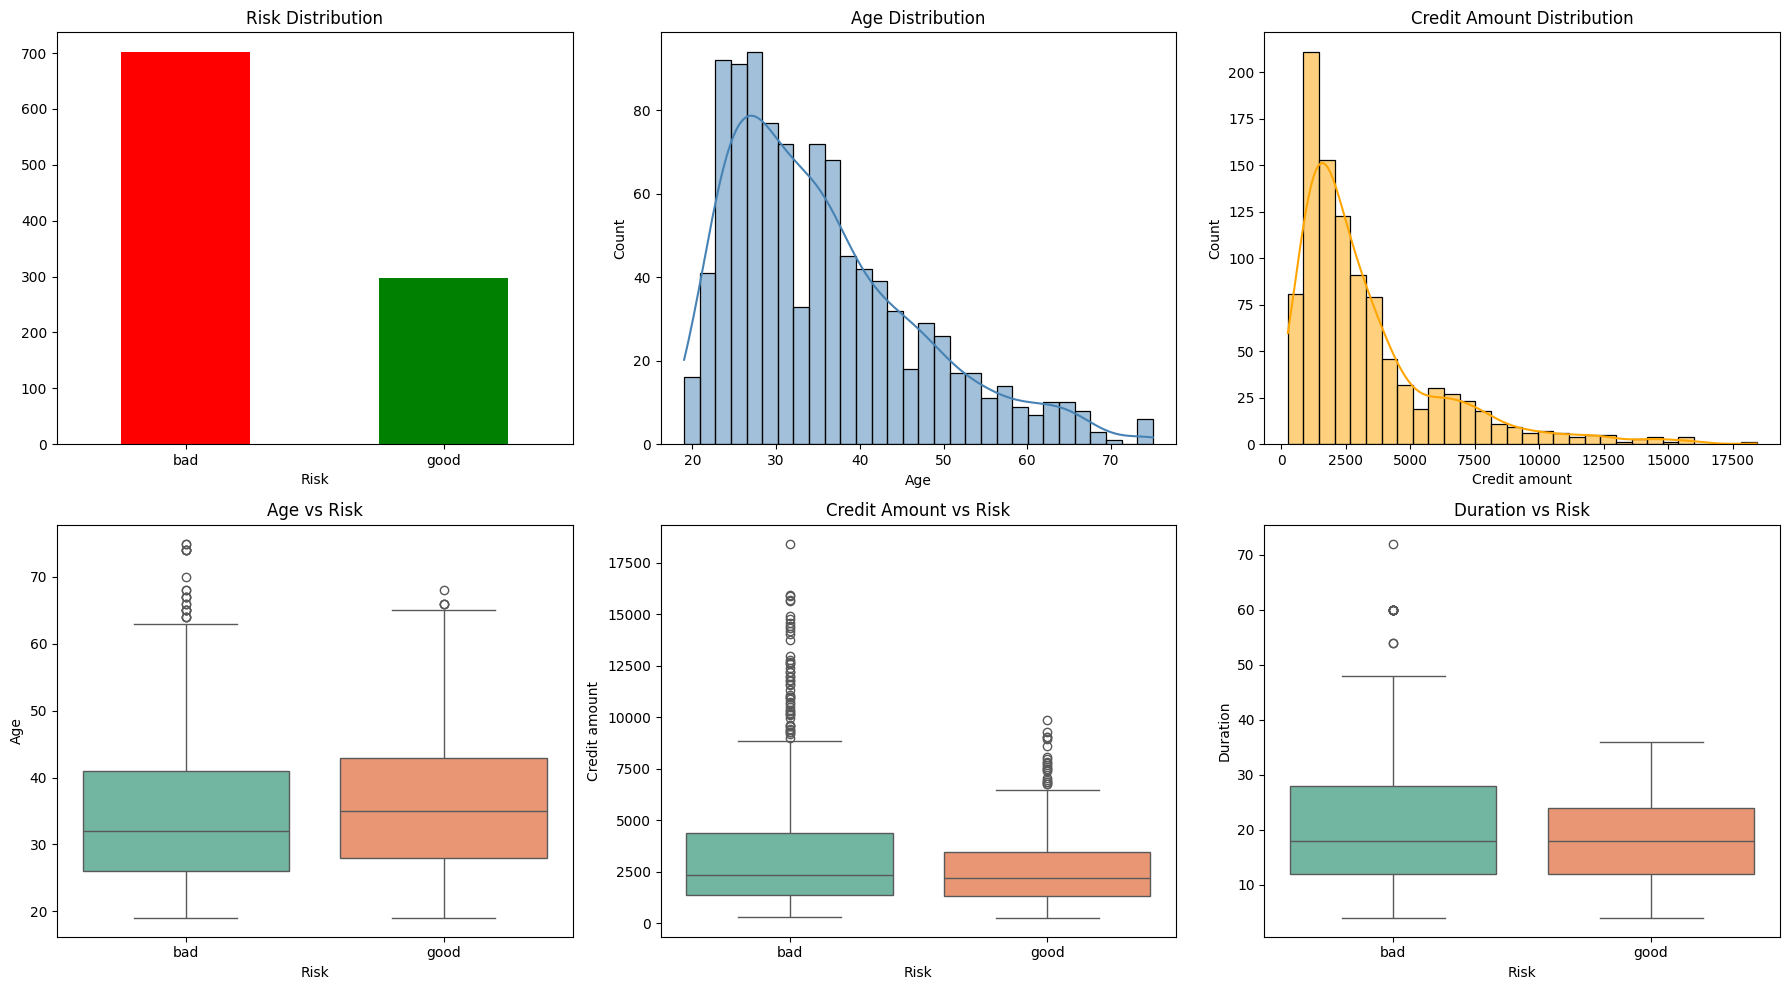

EDA Done ✅


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Risk Distribution
df['Risk'].value_counts().plot(kind='bar',
    color=['red','green'], ax=axes[0][0])
axes[0][0].set_title('Risk Distribution')
axes[0][0].tick_params(axis='x', rotation=0)

# Age Distribution
sns.histplot(df['Age'], bins=30, kde=True,
    color='steelblue', ax=axes[0][1])
axes[0][1].set_title('Age Distribution')

# Credit Amount Distribution
sns.histplot(df['Credit amount'], bins=30, kde=True,
    color='orange', ax=axes[0][2])
axes[0][2].set_title('Credit Amount Distribution')

# Age vs Risk
sns.boxplot(x='Risk', y='Age', data=df,
    palette='Set2', ax=axes[1][0])
axes[1][0].set_title('Age vs Risk')

# Credit Amount vs Risk
sns.boxplot(x='Risk', y='Credit amount', data=df,
    palette='Set2', ax=axes[1][1])
axes[1][1].set_title('Credit Amount vs Risk')

# Duration vs Risk
sns.boxplot(x='Risk', y='Duration', data=df,
    palette='Set2', ax=axes[1][2])
axes[1][2].set_title('Duration vs Risk')

plt.tight_layout()
plt.show()
print("EDA Done ✅")

In [7]:
df_model = df.copy()

le = LabelEncoder()
cat_cols = ['Sex', 'Housing', 'Saving accounts',
            'Checking account', 'Purpose', 'Risk']

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

print("Encoding Done ✅")
df_model.head()

Encoding Done ✅


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,1,2,1,0,0,1169,6,5,0
1,22,0,2,1,0,1,5951,48,5,0
2,49,1,1,1,0,0,2096,12,3,0
3,45,1,2,0,0,0,7882,42,4,0
4,53,1,2,0,0,0,4870,24,1,0


In [8]:
X = df_model.drop(columns=['Risk'])
y = df_model['Risk']

# Handle class imbalance
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Before SMOTE:", y.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_resampled).value_counts().to_dict())

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nTrain size:", X_train.shape)
print("Test size:", X_test.shape)
print("Preprocessing Done ✅")

Before SMOTE: {0: 702, 1: 298}
After SMOTE: {0: 702, 1: 702}

Train size: (1123, 9)
Test size: (281, 9)
Preprocessing Done ✅


In [9]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest Trained ✅")

Random Forest Trained ✅


In [10]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:,1]

print("=== Random Forest Results ===")
print(f"Accuracy  : {round(accuracy_score(y_test, y_pred), 4)}")
print(f"Precision : {round(precision_score(y_test, y_pred), 4)}")
print(f"Recall    : {round(recall_score(y_test, y_pred), 4)}")
print(f"F1-Score  : {round(f1_score(y_test, y_pred), 4)}")
print(f"ROC-AUC   : {round(roc_auc_score(y_test, y_prob), 4)}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

=== Random Forest Results ===
Accuracy  : 0.8149
Precision : 0.8729
Recall    : 0.7357
F1-Score  : 0.7984
ROC-AUC   : 0.8968

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.77      0.89      0.83       141
           1       0.87      0.74      0.80       140

    accuracy                           0.81       281
   macro avg       0.82      0.81      0.81       281
weighted avg       0.82      0.81      0.81       281



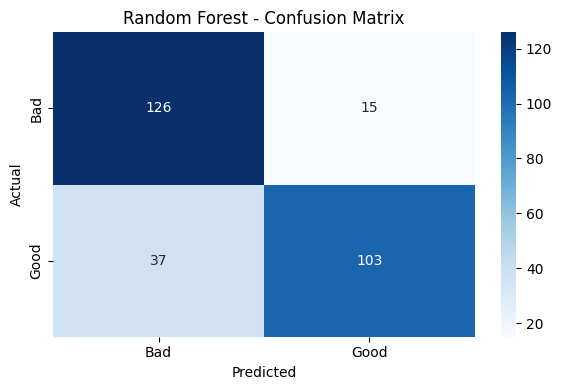

In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d',
            cmap='Blues',
            xticklabels=['Bad', 'Good'],
            yticklabels=['Bad', 'Good'])
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

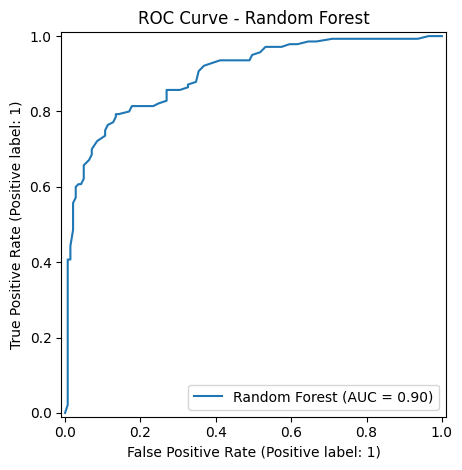

In [12]:
plt.figure(figsize=(8, 5))
RocCurveDisplay.from_estimator(
    rf_model, X_test, y_test,
    name='Random Forest'
)
plt.title('ROC Curve - Random Forest')
plt.tight_layout()
plt.show()

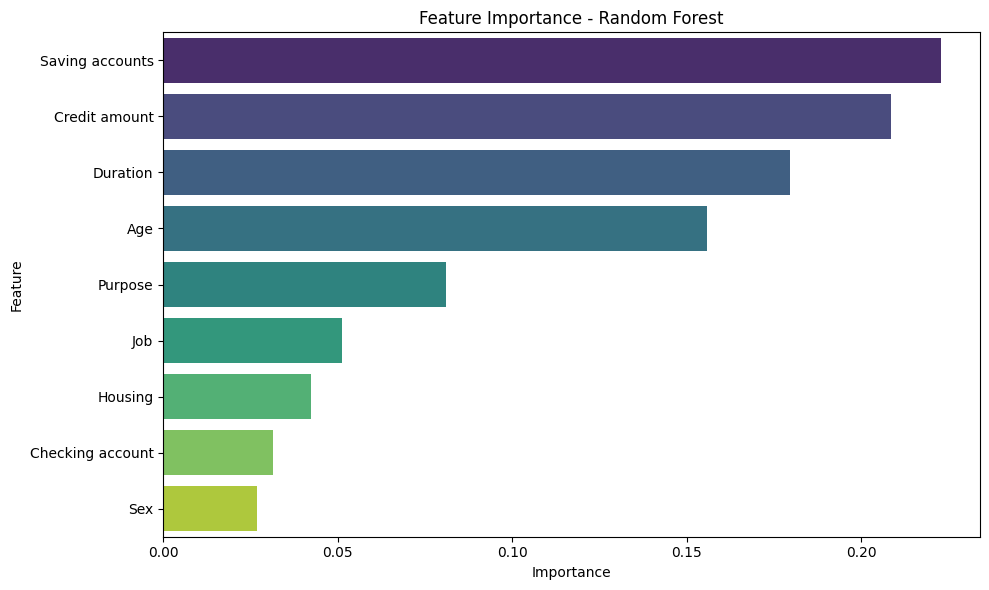

            Feature  Importance
4   Saving accounts    0.222982
6     Credit amount    0.208668
7          Duration    0.179631
0               Age    0.155934
8           Purpose    0.080980
2               Job    0.051165
3           Housing    0.042337
5  Checking account    0.031421
1               Sex    0.026880


In [13]:
feature_names = df_model.drop(columns=['Risk']).columns
importances = rf_model.feature_importances_

feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature',
            data=feat_df, palette='viridis')
plt.title('Feature Importance - Random Forest')
plt.tight_layout()
plt.show()

print(feat_df)

In [14]:
print("=" * 50)
print("  CREDITWORTHINESS PREDICTION - FINAL SUMMARY")
print("=" * 50)
print(f"  Model     : Random Forest")
print(f"  Accuracy  : {round(accuracy_score(y_test, y_pred), 4)}")
print(f"  Precision : {round(precision_score(y_test, y_pred), 4)}")
print(f"  Recall    : {round(recall_score(y_test, y_pred), 4)}")
print(f"  F1-Score  : {round(f1_score(y_test, y_pred), 4)}")
print(f"  ROC-AUC   : {round(roc_auc_score(y_test, y_prob), 4)}")
print("=" * 50)

  CREDITWORTHINESS PREDICTION - FINAL SUMMARY
  Model     : Random Forest
  Accuracy  : 0.8149
  Precision : 0.8729
  Recall    : 0.7357
  F1-Score  : 0.7984
  ROC-AUC   : 0.8968
